# NLP Primer

## What is Language

Language is a structured system of communication that involves complex combinations of its constituent components, such as characters, words, sentences, etc. Linguistics is the systematic study of language. In order to study NLP, it is important to understand some concepts from linguistics about how language is structured. In this section, we’ll introduce them and cover how they relate to some of the NLP tasks we listed earlier.

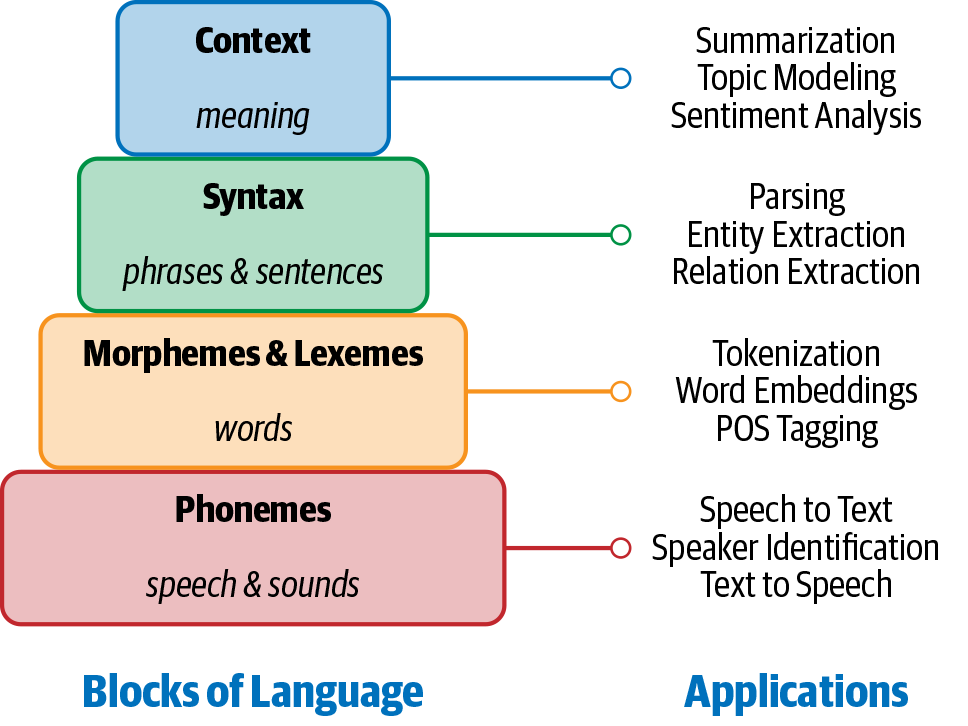

### Building Blocks Of Language

Let’s first introduce what these blocks of language are to give context for the challenges involved in NLP.

#### Phonemes

Phonemes are the smallest units of sound in a language.

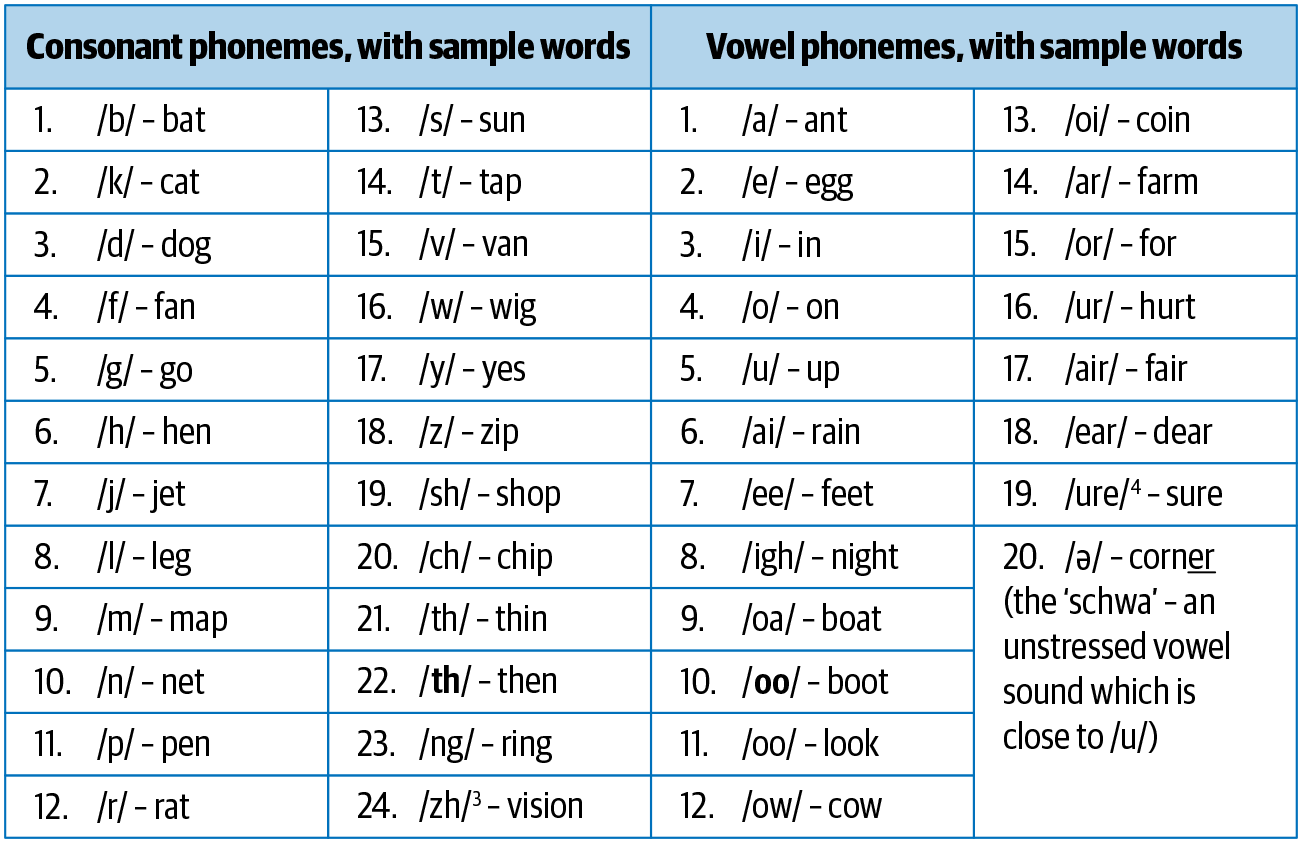


#### Morphemes and lexemes

A morpheme is the smallest unit of language that has a meaning. It is formed by a combination of phonemes. Not all morphemes are words, but all prefixes and suffixes are morphemes. For example, in the word “multimedia,” “multi-” is not a word but a prefix that changes the meaning when put together with “media.” “Multi-” is a morpheme.

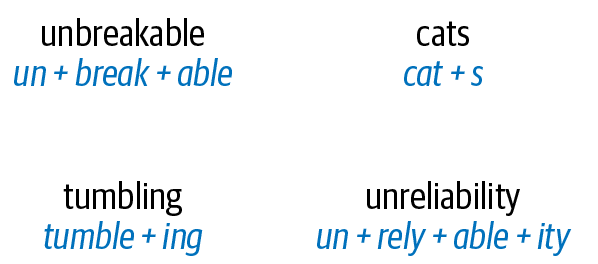


#### Syntax

Syntax is a set of rules to construct grammatically correct sentences out of words and phrases in a language. Syntactic structure in linguistics is represented in many different ways. A common approach to representing sentences is a parse tree. Figure 1-6 shows an example parse tree for two English sentences.

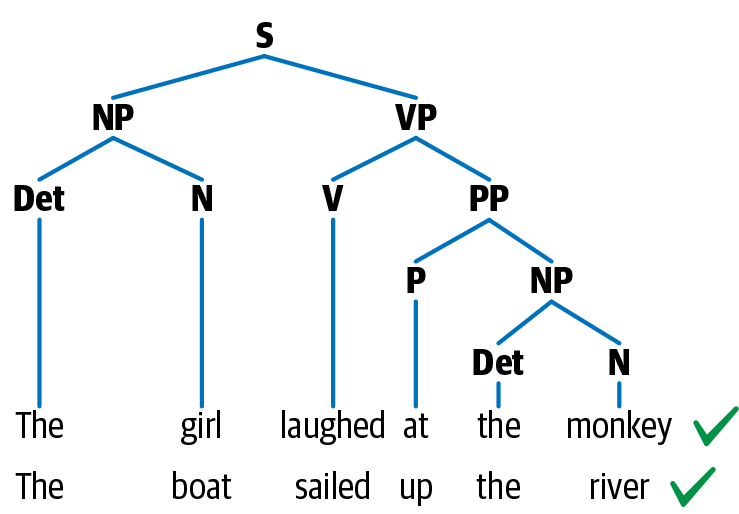

In Figure 1-6, both sentences have a similar structure and hence a similar syntactic parse tree. In this representation, N stands for noun, V for verb, and P for preposition. Noun phrase is denoted by NP and verb phrase by VP. The two noun phrases are “The girl” and “The boat,” while the two verb phrases are “laughed at the monkey” and “sailed up the river.” The syntactic structure is guided by a set of grammar rules for the language (e.g., the sentence comprises an NP and a VP), and this in turn guides some of the fundamental tasks of language processing, such as parsing. Parsing is the NLP task of constructing such trees automatically.


#### Context

Context is how various parts in a language come together to convey a particular meaning. Context includes long-term references, world knowledge, and common sense along with the literal meaning of words and phrases.


# Text preprocessing


## Tokenization

### What is tokenization?

Tokenization is the process of breaking down text into smaller units called tokens. These tokens can be words, subwords, or even characters. The choice of tokenization method depends on the specific NLP task and the language being processed. For example, in English, word-level tokenization is common, while in languages like Chinese, character-level tokenization may be more appropriate.

#### Sentence and word tokenization


In [2]:
# Import nltk
import nltk
# Download the punkt_tab package 
nltk.download("punkt_tab")
nltk.download("wordnet")

text = """
The stock market saw a significant dip today. Experts believe the downturn may continue.
However, many investors are optimistic about future growth.
"""

# Tokenize the text into sentences
sentences = nltk.sent_tokenize(text)
print(sentences)

[nltk_data] Downloading package punkt_tab to /home/shk/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /home/shk/nltk_data...


['\nThe stock market saw a significant dip today.', 'Experts believe the downturn may continue.', 'However, many investors are optimistic about future growth.']


In [3]:
import nltk
nltk.download('punkt_tab')

text = """
The stock market saw a significant dip today. Experts believe the downturn may continue.
However, many investors are optimistic about future growth.
"""

sentences = nltk.sent_tokenize(text)

# Tokenize the first sentence into words
words = nltk.word_tokenize(sentences[0])
print(words)

['The', 'stock', 'market', 'saw', 'a', 'significant', 'dip', 'today', '.']


[nltk_data] Downloading package punkt_tab to /home/shk/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Stop words and punctuation handling


### Removing stop words


In [5]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
feedback = "I reached out to support and got a helpful response within minutes!!! Very #impressed"
# Tokenize the text
tokens = word_tokenize(feedback)

# Get the list of English stop words
stop_words = stopwords.words('english')

# Remove stop words 
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]

print(filtered_tokens)

['reached', 'support', 'got', 'helpful', 'response', 'within', 'minutes', '!', '!', '!', '#', 'impressed']


In [6]:
import string

filtered_tokens = ['reached', 'support', 'got', 'helpful', 'response', 'within', 'minutes', '!', '!', '!', '#', 'impressed']

# Remove punctuation
clean_tokens = [word for word in filtered_tokens if word not in string.punctuation]

print(clean_tokens)

['reached', 'support', 'got', 'helpful', 'response', 'within', 'minutes', 'impressed']


## Lowercasing


In [7]:
review = "I have been FLYING a lot lately and the Flights just keep getting DELAYED. Honestly, traveling for WORK gets exhausting with endless delays, but every trip teaches you something new!"

# Lowercase the review
lower_text = review.lower()

# Tokenize the lower_text into words
tokens = word_tokenize(lower_text)

# Remove stop words and punctuation
clean_tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]

print(clean_tokens)

['flying', 'lot', 'lately', 'flights', 'keep', 'getting', 'delayed', 'honestly', 'traveling', 'work', 'gets', 'exhausting', 'endless', 'delays', 'every', 'trip', 'teaches', 'something', 'new']


## Stemming


In [9]:
from nltk.stem import PorterStemmer

clean_tokens = ['flying', 'lot', 'lately', 'flights', 'keep', 'getting', 'delayed', 'honestly', 'traveling', 'work', 'gets', 'exhausting', 'endless', 'delays', 'every', 'travel', 'teaches', 'something', 'new']

# Create stemmer
stemmer = PorterStemmer()

# Stem each token
stemmed_tokens = [stemmer.stem(word) for word in clean_tokens]

print(stemmed_tokens)

['fli', 'lot', 'late', 'flight', 'keep', 'get', 'delay', 'honestli', 'travel', 'work', 'get', 'exhaust', 'endless', 'delay', 'everi', 'travel', 'teach', 'someth', 'new']


## Lemmatization


In [12]:
# Install nltk if not already installed
from nltk.stem import WordNetLemmatizer

# clean_tokens is already defined in previous cells

# Create lemmatizer
lemmatizer = WordNetLemmatizer()

# Lemmatize each token
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in clean_tokens]

print(lemmatized_tokens)

['flying', 'lot', 'lately', 'flight', 'keep', 'getting', 'delayed', 'honestly', 'traveling', 'work', 'get', 'exhausting', 'endless', 'delay', 'every', 'travel', 'teach', 'something', 'new']


# Feature Extraction from Text (Text Representation)


Transform raw text into powerful numerical features. Create Bag-of-Words and TF-IDF representations to capture word importance across documents, then explore word embeddings like Word2Vec and GloVe to uncover deep semantic patterns. Visualize frequency, relevance, and similarity to bring your text data to life.


## Bag of Words (BoW)


- BOW is to represent text as a collection of words as numbers.
- Represent text by counting how often each word appears in the text.
- Throws words in a bag and counts them.


In [22]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in string.punctuation]
    return " ".join(tokens)

In [19]:
reviews = [
    "The product is fantastic! It works like a charm.",
    "I hated the product. It broke after one use.",
    "Product was okay, not the best, but fine overall."
]
# Preprocess the reviews
cleaned_reviews = [preprocess(review) for review in reviews]

vectorizer = CountVectorizer()
# Fit_Transform the vectorizer
X = vectorizer.fit_transform(cleaned_reviews)
# Print the vocabulary 
print(vectorizer.get_feature_names_out())

['after' 'best' 'broke' 'but' 'charm' 'fantastic' 'fine' 'hated' 'is' 'it'
 'like' 'not' 'okay' 'one' 'overall' 'product' 'the' 'use' 'was' 'works']


In [20]:
print(X.toarray())

[[0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 1 0 0 1]
 [1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0]
 [0 1 0 1 0 0 1 0 0 0 0 1 1 0 1 1 1 0 1 0]]


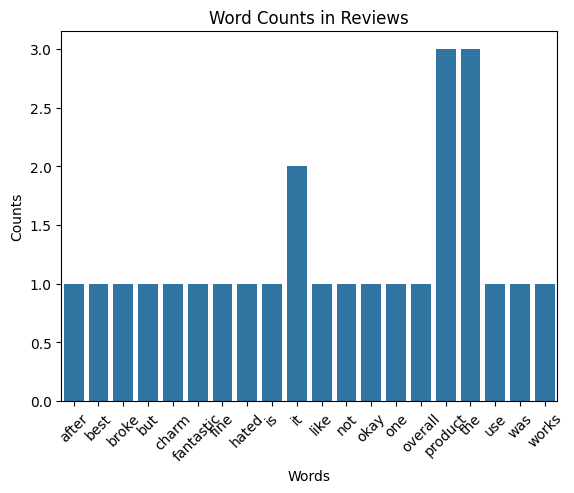

In [28]:
# Get word counts
word_counts = np.sum(X.toarray(), axis=0)
# Get words
words = vectorizer.get_feature_names_out()

sns.barplot(x=words, y=word_counts)
plt.title("Word Counts in Reviews")
plt.xlabel("Words")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.show()